| Parameter | Tested values | Selected value |
|-----------|---------------|----------------|
| λ (smoothing parameter) | 1e4, 1e5, 1e6, 1e7 | **1e5** |
| Peak weight | 0.1, 0.3, 0.5 | **0.3** |
| Peak window | 15, 25, 35 | **35** |

## 1. Lambda sensitivity analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prospecpy.baseline import (
    arpls_baseline_second_deriv_weights
)

In [2]:
import pandas as pd

data = pd.read_csv(
    "output_plots/pH6/011a as iso Hyd2 dark titration 0 mV.0022/cut_subtracted_data.csv"
)

data.head()

,wavenumber,cut_subtracted_absorbance
0,2149.439805,0.201716
1,2147.512303,0.192439
2,2145.584802,0.182981
3,2143.657300,0.176096
4,2141.729798,0.170866


In [3]:
x = data["wavenumber"].values

y = data["cut_subtracted_absorbance"].values

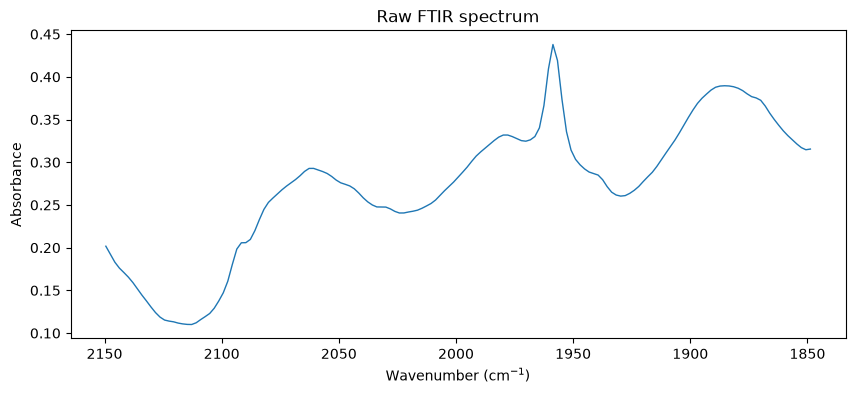

In [4]:
plt.figure(figsize=(10,4))

plt.plot(
    x,
    y,
    linewidth=1
)

plt.xlabel(
    "Wavenumber (cm$^{-1}$)"
)

plt.ylabel(
    "Absorbance"
)

plt.gca().invert_xaxis()

plt.title(
    "Raw FTIR spectrum"
)

plt.show()

In [5]:
peak_data = pd.read_csv(
    "output_plots/pH6/011a as iso Hyd2 dark titration 0 mV.0022/arpls_baseline_corrected_peak_info.csv"
)

peak_data.head()

,peak_index,wavenumber,absorbance
0,366,1958.276276,0.110289
1,813,2092.957958,0.019569


In [6]:
peak_wavenumbers = peak_data["wavenumber"].values

peak_wavenumbers

array([1958.27627628, 2092.95795796])

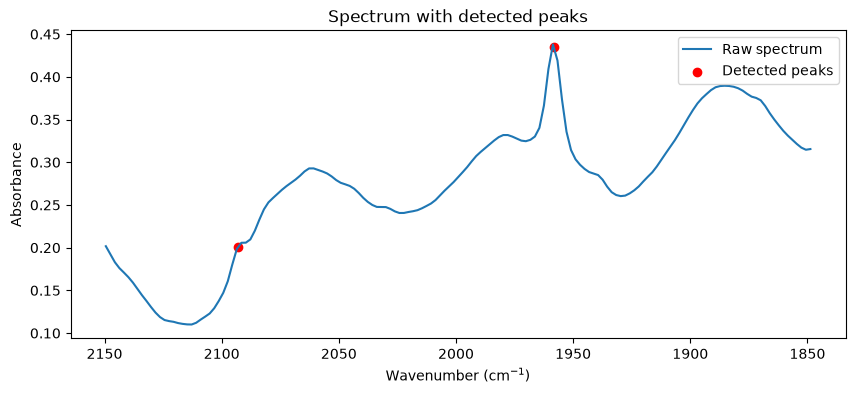

In [7]:
plt.figure(figsize=(10,4))

plt.plot(
    x,
    y,
    label="Raw spectrum"
)

plt.scatter(
    peak_wavenumbers,
    np.interp(
        peak_wavenumbers,
        x[::-1],
        y[::-1]
    ),
    color="red",
    label="Detected peaks"
)

plt.xlabel(
    "Wavenumber (cm$^{-1}$)"
)

plt.ylabel(
    "Absorbance"
)

plt.gca().invert_xaxis()

plt.legend()

plt.title(
    "Spectrum with detected peaks"
)

plt.show()

In [8]:
lambda_values = [
    1e4,
    1e5,
    1e6,
    1e7
]

In [9]:
baseline_results = {}

for lam in lambda_values:

    baseline = arpls_baseline_second_deriv_weights(
        y,
        x,
        peak_wavenumbers,
        lam=lam,
        ratio=1e-6,
        max_iter=50,
        peak_window=35,
        peak_weight=0.3,
        alpha=0.8,
    )

    baseline_results[lam] = baseline

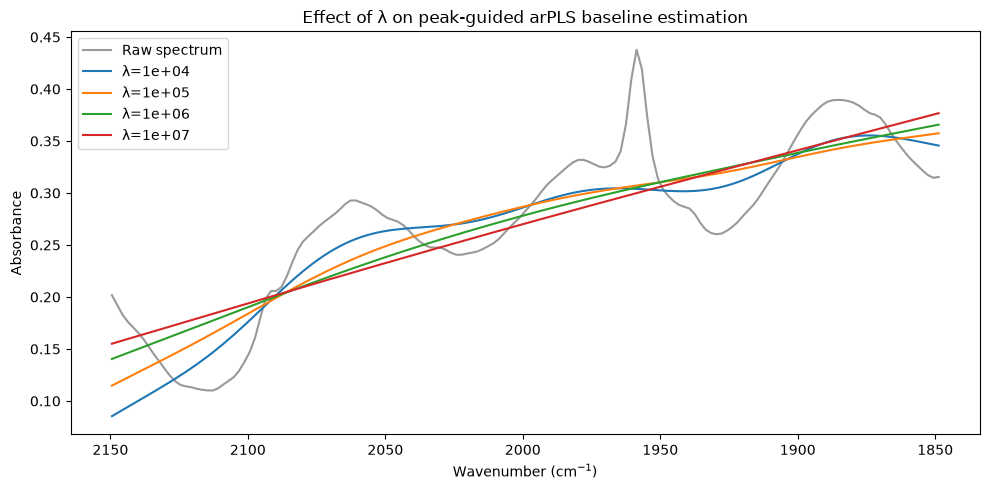

In [10]:
plt.figure(figsize=(10,5)) 

plt.plot(
    x,
    y,
    color="black",
    alpha=0.4,
    label="Raw spectrum"
)

for lam, baseline in baseline_results.items():

    plt.plot(
        x,
        baseline,
        label=f"λ={lam:.0e}"
    )


plt.xlabel(
    "Wavenumber (cm$^{-1}$)"
)

plt.ylabel(
    "Absorbance"
)

plt.gca().invert_xaxis()

plt.legend()

plt.title(
    "Effect of λ on peak-guided arPLS baseline estimation"
)

plt.tight_layout()

plt.show()

In [12]:
def calculate_smoothness(baseline): 
    second_derivative = np.diff(
        baseline,
        n=2
    )
    
    return np.sum(
        np.abs(second_derivative)
    )


for lam, baseline in baseline_results.items():

    lam_label = f"{lam:.0e}".replace("e+0", "e").replace("e+", "e")

    print(
        f"λ={lam_label}",
        calculate_smoothness(baseline)
    )

λ=1e4 0.016377163102367476
λ=1e5 0.00333829930809168
λ=1e6 0.0009744407019510737
λ=1e7 0.0001759681688744963


In [13]:
lambda_results = pd.DataFrame(
    {
        "lambda": [
            f"{lam:.0e}".replace("e+0", "e").replace("e+", "e")
            for lam in baseline_results.keys()
        ],
        "smoothness": [
            calculate_smoothness(b)
            for b in baseline_results.values()
        ],
    }
)

lambda_results

,lambda,smoothness
0,1e4,0.016377
1,1e5,0.003338
2,1e6,0.000974
3,1e7,0.000176


## Lambda selection

The influence of the smoothing parameter λ was evaluated using
four values (1e4, 1e5, 1e6 and 1e7).

Increasing λ produced progressively smoother baselines, as indicated
by the decreasing second-derivative smoothness metric.

However, excessive smoothing may remove meaningful spectral variation.
The value λ = 1e5 provided a suitable balance between baseline
smoothness and preservation of spectral features.

Therefore, λ = 1e5 was selected for subsequent peak-guided arPLS
experiments.

## 2. peak_weight sensitivity

In [17]:
peak_weight_values = [
    0.1,
    0.3,
    0.5
]

In [18]:
peak_weight_results = {}

for weight in peak_weight_values:

    baseline = arpls_baseline_second_deriv_weights(
        y,
        x,
        peak_wavenumbers,
        lam=1e5,
        ratio=1e-6,
        max_iter=50,
        peak_window=35,
        peak_weight=weight,
        alpha=0.8,
    )

    peak_weight_results[weight] = baseline

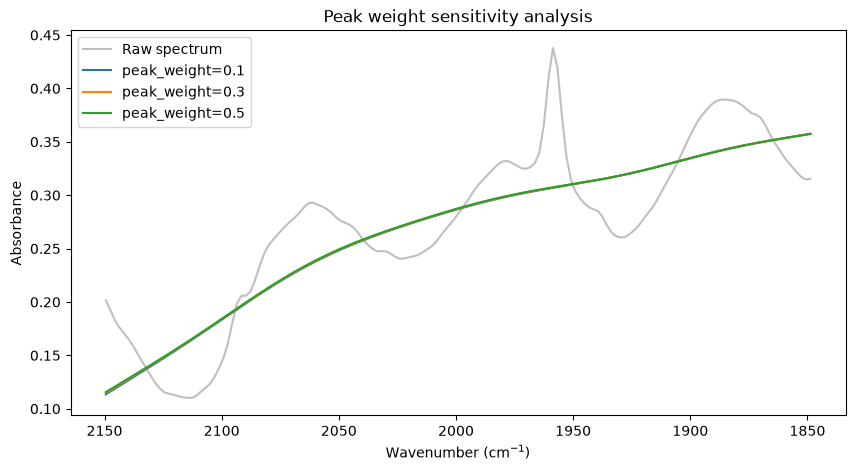

In [19]:
plt.figure(figsize=(10,5))


plt.plot(
    x,
    y,
    color="grey",
    alpha=0.5,
    label="Raw spectrum"
)


for weight, baseline in peak_weight_results.items():

    plt.plot(
        x,
        baseline,
        label=f"peak_weight={weight}"
    )


plt.xlabel(
    "Wavenumber (cm$^{-1}$)"
)

plt.ylabel(
    "Absorbance"
)


plt.gca().invert_xaxis()


plt.legend()

plt.title(
    "Peak weight sensitivity analysis"
)

plt.show()

In [20]:
def calculate_peak_deviation(
    x,
    spectrum,
    baseline,
    peak_position,
    window=15
):

    peak_region = (
        np.abs(x - peak_position)
        < window
    )

    deviation = np.mean(
        spectrum[peak_region]
        -
        baseline[peak_region]
    )

    return deviation

In [21]:
peak_weight_metrics = []


for weight, baseline in peak_weight_results.items():

    deviation = calculate_peak_deviation(
        x,
        y,
        baseline,
        peak_wavenumbers[0],
    )

    peak_weight_metrics.append(
        {
            "peak_weight": weight,
            "peak_deviation": deviation
        }
    )


pd.DataFrame(
    peak_weight_metrics
)

,peak_weight,peak_deviation
0,0.1,0.039517
1,0.3,0.039269
2,0.5,0.039059


## Peak weight selection

The influence of the peak weight parameter was evaluated using
three values: 0.1, 0.3 and 0.5.

The resulting baseline profiles showed minimal differences,
indicating that the peak-guided arPLS method is relatively robust
to this parameter.

The peak deviation metric also showed similar values across the
tested range. A value of 0.3 was retained because it provides a
balanced weighting strategy: sufficient reduction of peak influence
without excessively suppressing spectral regions around peaks.

## 3. peak_window sensitivity

In [22]:
peak_window_values = [
    15,
    25,
    35
]

In [23]:
peak_window_results = {}

for window in peak_window_values:

    baseline = arpls_baseline_second_deriv_weights(
        y,
        x,
        peak_wavenumbers,
        lam=1e5,
        ratio=1e-6,
        max_iter=50,
        peak_window=window,
        peak_weight=0.3,
        alpha=0.8,
    )

    peak_window_results[window] = baseline

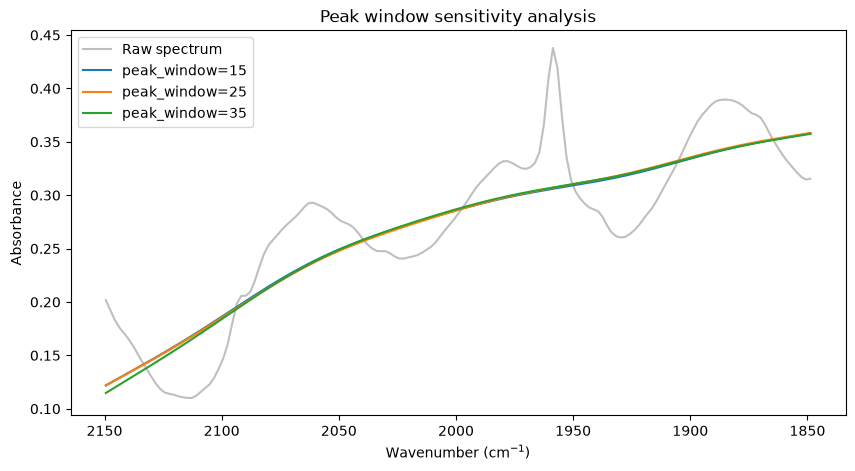

In [24]:
plt.figure(figsize=(10,5))


plt.plot(
    x,
    y,
    color="grey",
    alpha=0.5,
    label="Raw spectrum"
)


for window, baseline in peak_window_results.items():

    plt.plot(
        x,
        baseline,
        label=f"peak_window={window}"
    )


plt.xlabel(
    "Wavenumber (cm$^{-1}$)"
)

plt.ylabel(
    "Absorbance"
)

plt.gca().invert_xaxis()

plt.legend()

plt.title(
    "Peak window sensitivity analysis"
)

plt.show()

In [25]:
peak_window_metrics = []


for window, baseline in peak_window_results.items():

    deviation = calculate_peak_deviation(
        x,
        y,
        baseline,
        peak_wavenumbers[0],
    )

    peak_window_metrics.append(
        {
            "peak_window": window,
            "peak_deviation": deviation
        }
    )


peak_window_results_table = pd.DataFrame(
    peak_window_metrics
)


peak_window_results_table

,peak_window,peak_deviation
0,15,0.040450
1,25,0.039526
2,35,0.039269


## Peak window selection

The peak window parameter was evaluated using values of 15, 25 and 35.
Only minor differences were observed between the resulting baselines,
indicating that the method is robust to this parameter.

A peak window of 35 was retained as it provides a wider protection region
around detected peaks while maintaining stable baseline estimation.

| Parameter | Tested values | Selected value |
|-----------|---------------|----------------|
| λ | 1e4, 1e5, 1e6, 1e7 | **1e5** |
| peak_weight | 0.1, 0.3, 0.5 | **0.3** |
| peak_window | 15, 25, 35 | **35** |

## Parameter selection summary

Sensitivity analysis was performed to justify the selected parameters
for the peak-guided arPLS baseline correction method.

The smoothing parameter λ was evaluated using values from 1e4 to 1e7.
Increasing λ produced smoother baselines, but excessive smoothing reduced
baseline flexibility. Therefore, λ = 1e5 was selected as a balance between
smoothness and preservation of spectral features.

The peak weight parameter was evaluated using values of 0.1, 0.3 and 0.5.
Only minor differences were observed, indicating robustness to this
parameter. A value of peak_weight = 0.3 was retained as a balanced weighting
factor.

The peak window parameter was evaluated using values of 15, 25 and 35.
The resulting baselines showed similar trends across the tested range.
A value of peak_window = 35 was selected to provide sufficient protection
around detected peaks while maintaining stable baseline estimation.

The final parameters used for subsequent experiments were:
λ = 1e5, peak_weight = 0.3, and peak_window = 35.